In [1]:
print('Hellow World')

Hellow World


In [4]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder,StandardScaler
import pickle  #TO SAVE MODEL
import joblib  #TO SAVE MODEL

In [ ]:
#                                    LOAD THE DATA 

In [3]:
df=pd.read_csv(r'C:\Users\amank\Downloads\cardekho.csv')
df.head(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [ ]:
#                              CHECK FOR NULL VALUES 

In [ ]:
df.isnull().sum()  

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

In [ ]:
#                                 DROP DUPLICATES

In [22]:
df.drop_duplicates(inplace=True)

In [23]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#                         RENAME COLUMNS IF NEEDED

In [24]:
df.rename(columns={'mileage(km/ltr/kg)':'mileage'},inplace=True)

In [ ]:
#                          DROP COLUMNS THAT ARE NOT NEEDED

In [25]:
df.drop(columns=['name','max_power'],inplace=True)

In [26]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,5.0


In [ ]:
#                             REMOVE THE NULL VALUES

In [28]:
df['engine']=df['engine'].fillna(df['engine'].mean())
df['mileage']=df['mileage'].fillna(df['mileage'].mean())
df['seats']=df['seats'].fillna(df['seats'].mean())

In [29]:
df.isnull().sum()

year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
seats            0
dtype: int64

In [ ]:
#                  ENCODE THE DATA USING LABEL ENCODER

In [75]:
label=LabelEncoder()

In [33]:
df['encoded_fuel']=LabelEncoder().fit_transform(df['fuel'])
df['encoded_transmission']=LabelEncoder().fit_transform(df['transmission'])
df['encoded_owner']=LabelEncoder().fit_transform(df['owner'])
df['encoded_seller_type']=LabelEncoder().fit_transform(df['seller_type'])

In [ ]:
#   FILTERING METHOD DROP COLUMNS THAT ARE NOT NEEDED AFTER ENCODING

In [38]:
df.drop(columns=['fuel','seller_type','transmission','owner'],inplace=True)

In [39]:
df.head(5)

,year,selling_price,km_driven,mileage,engine,seats,encoded_fuel,encoded_transmission,encoded_owner,encoded_seller_type
0,2014,450000,145500,23.40,1248.0,5.0,1,1,0,1
1,2014,370000,120000,21.14,1498.0,5.0,1,1,2,1
2,2006,158000,140000,17.70,1497.0,5.0,3,1,4,1
3,2010,225000,127000,23.00,1396.0,5.0,1,1,0,1
4,2007,130000,120000,16.10,1298.0,5.0,3,1,0,1


In [ ]:
#                  FIND THE CORRELATION BETWEEN THE COLUMNS

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
var=df[['year','selling_price','km_driven','engine','mileage','seats']].corr()
var

,year,selling_price,km_driven,engine,mileage,seats
year,1.000000,0.433076,-0.377003,-0.017967,0.345414,0.022260
selling_price,0.433076,1.000000,-0.165620,0.439321,-0.107479,0.156849
km_driven,-0.377003,-0.165620,1.000000,0.250966,-0.194653,0.206010
engine,-0.017967,0.439321,0.250966,1.000000,-0.578483,0.657798
mileage,0.345414,-0.107479,-0.194653,-0.578483,1.000000,-0.459624
seats,0.022260,0.156849,0.206010,0.657798,-0.459624,1.000000


In [ ]:
#               MAKE HEATMAP OF THE CORRELATION BETWEEN THE COLUMNS

<Axes: >

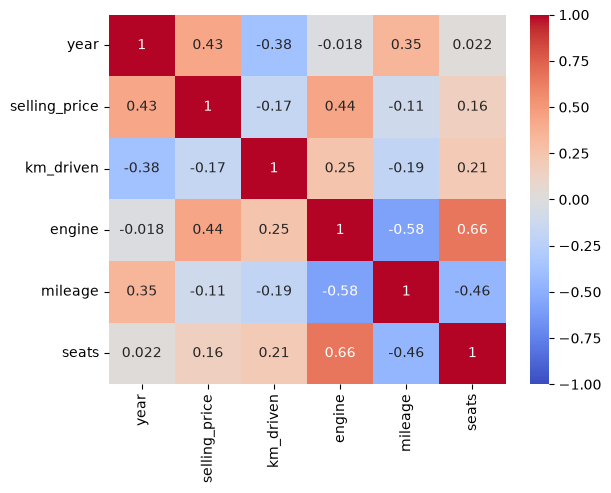

In [43]:
sns.heatmap(var,annot=True,vmin=-1,vmax=1,cmap='coolwarm')

In [ ]:
#                      GIVE VALUES TO X AXIS AND Y AXIS

In [65]:
x=df[['year','km_driven','engine','mileage','seats']]
y=df['selling_price']

In [ ]:
#              SPLIT THE DATA INTO TRAINING AND TESTING DATA

In [47]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#                      SELECT MODEL FOR TARING THE DATA

In [48]:
model=RandomForestRegressor(max_depth=10,n_estimators=100,random_state=42)

In [ ]:
#                               TRAIN THE DATA

In [66]:
model.fit(x_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [ ]:
#                                 PRDICTION TEST

In [68]:
y_pred=model.predict(x_train)
r2=r2_score(y_train,y_pred)
print(f'r2_score(train): {r2:.4f}')

r2_score(train): 0.9499


In [ ]:
y_pred=model.predict(x_test)
r2=r2_score(y_test,y_pred)
print(f'r2_score(test):{r2:.4f}')

r2_score(test):0.7926


In [ ]:
#                         SAVE THE MODEL USING PICKLE

In [73]:
joblib.dump(model,'car_price_prediction_model.pkl')

['car_price_prediction_model.pkl']

In [ ]:
#                      THIS IS HOW TO LOAD THE SAVED MODEL.

In [71]:
model=joblib.load('car_price_prediction_model.pkl')

In [ ]:
#                              PRICE PRDICTION TEST.

In [72]:
model.predict([[2015, 1200, 5, 20, 5]])

c:\Users\amank\Downloads\Learning_day_1\aman\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([349732.78857454])